# clustering_v1 — UMAP, HDBSCAN, and validation baselines (ARCHIVED)

> **Team 1 pipeline:** see [clustering_v2.ipynb](clustering_v2.ipynb). This notebook keeps exploratory runs (UMAP-primary, method comparison, noise sweep).

Stratified sample from `dev_profile_final_v4` (activated + activity in last 180 days), then:
- **Primary:** UMAP + HDBSCAN on scaled numeric features
- **Validation:** PCA+K-Means, SVD+HDBSCAN, SVD+Leiden (optional), Bayesian GMM

**Prerequisite:** Run [FeatureEngineering_v3.ipynb](FeatureEngineering_v3.ipynb) through §14 so `dev_profile_final_v4` exists in `developer_project.duckdb`.

**v1 scope:** 100k stratified sample only. **§10** clusters **separately** by dormancy stratum (Active, Cooling, Dormant). Full-population scoring and supervised lift tests are deferred.


In [1]:
import warnings
from pathlib import Path

from IPython.display import display

import duckdb
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.impute import SimpleImputer
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.mixture import BayesianGaussianMixture
from sklearn.cluster import KMeans
from sklearn.neighbors import kneighbors_graph
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
import hdbscan
import umap

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

# --- Config ---
DB_PATH = "developer_project.duckdb"
OUTPUT_DIR = Path("outputs/clustering")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_N = 100_000
RANDOM_STATE = 42
HASH_SALT = 42

UMAP_PARAMS = dict(n_components=2, n_neighbors=30, min_dist=0.1, metric="euclidean", random_state=RANDOM_STATE)
HDBSCAN_MIN_CLUSTER_FRAC = 0.007  # ~700 clusters min size at 100k
HDBSCAN_MIN_SAMPLES = 25
SVD_COMPONENTS = 50
KNN_K = 15

con = duckdb.connect(DB_PATH)
print("Connected:", DB_PATH)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Connected: developer_project.duckdb


In [32]:
display(con.execute("""
    SELECT
        developer_id,
        persona,
        dormancy_status,
        final_lifecycle_status,
        current_journey_state_30d,
        is_activated,
        has_activity_0_30d,
        has_activity_30_90d,
        has_activity_90_180d,
        activity_count_0_30d,
        days_since_last_activity,
        developer_effort_score
    FROM dev_profile_final_v4
    LIMIT 20
""").fetchdf())

,developer_id,persona,dormancy_status,final_lifecycle_status,current_journey_state_30d,is_activated,has_activity_0_30d,has_activity_30_90d,has_activity_90_180d,activity_count_0_30d,days_since_last_activity,developer_effort_score
0,3828153,CUDA,Dormant,Tourist,Dormant_Historically_Active,1,0,0,0,0,1023,0.362977
1,3828651,GenAI,Dormant,Tourist,Dormant_Historically_Active,1,0,0,0,0,1022,0.245482
2,3829434,CUDA,Dormant,Tourist,Dormant_Historically_Active,1,0,0,0,0,1022,0.396348
3,3828826,CUDA,Dormant,Dormant_Build,Dormant_Historically_Active,1,0,0,0,0,709,0.645169
4,3830677,CUDA,Dormant,Tourist,Dormant_Historically_Active,1,0,0,0,0,1022,0.362977
5,3831320,CUDA,Dormant,Tourist,Dormant_Historically_Active,1,0,0,0,0,1021,0.362977
6,3831296,GenAI,Dormant,Tourist,Dormant_Historically_Active,1,0,0,0,0,1021,0.245482
7,3831902,Robotics,Dormant,Dormant_Champion,Dormant_Builder,1,0,0,0,0,629,0.972651
8,3832363,CUDA,Dormant,Tourist,Dormant_Historically_Active,1,0,0,0,0,1021,0.362977
9,3832652,Robotics,Dormant,Tourist,Dormant_Historically_Active,1,0,0,0,0,1021,0.406753


## 1. Cohort and stratified sample

**Cohort:** `is_activated = 1` and activity in any of the last three 60-day windows (0–30d, 30–90d, 90–180d).

**Sample:** proportional stratification on `dormancy_status` × `persona`, target `SAMPLE_N` developers.


In [2]:
COHORT_SQL = """
CREATE OR REPLACE VIEW clustering_cohort_v1 AS
SELECT *
FROM dev_profile_final_v4
WHERE is_activated = 1
  AND (
        COALESCE(has_activity_0_30d, 0) = 1
     OR COALESCE(has_activity_30_90d, 0) = 1
     OR COALESCE(has_activity_90_180d, 0) = 1
  )
  AND COALESCE(dormancy_status, 'Unactivated') <> 'Unactivated'
"""

con.execute(COHORT_SQL)

cohort_stats = con.execute("""
SELECT
    COUNT(*) AS cohort_n,
    COUNT(DISTINCT dormancy_status) AS dormancy_levels,
    COUNT(DISTINCT persona) AS persona_levels
FROM clustering_cohort_v1
""").fetchdf()
display(cohort_stats)

display(con.execute("""
SELECT dormancy_status, persona, COUNT(*) AS n
FROM clustering_cohort_v1
GROUP BY 1, 2
ORDER BY n DESC
LIMIT 25
""").fetchdf())


,cohort_n,dormancy_levels,persona_levels
0,1231322,3,6


,dormancy_status,persona,n
0,Active,GenAI,292033
1,At_Risk,CUDA,174956
2,At_Risk,GenAI,157117
3,Cooling,GenAI,154741
4,Cooling,CUDA,101715
5,Active,CUDA,58072
6,At_Risk,Robotics,45883
7,Cooling,Robotics,33512
8,At_Risk,Learning_Community,32627
9,At_Risk,Unknown,32129


In [3]:
# Proportional stratified sample
con.execute(f"""
CREATE OR REPLACE TABLE clustering_sample_v1 AS
WITH cohort AS (
    SELECT * FROM clustering_cohort_v1
),
strata AS (
    SELECT
        dormancy_status,
        persona,
        COUNT(*) AS stratum_n
    FROM cohort
    GROUP BY 1, 2
),
targets AS (
    SELECT
        dormancy_status,
        persona,
        stratum_n,
        GREATEST(1, CAST(ROUND(stratum_n * 1.0 / SUM(stratum_n) OVER () * {SAMPLE_N}) AS BIGINT)) AS target_n
    FROM strata
),
ranked AS (
    SELECT
        c.*,
        ROW_NUMBER() OVER (
            PARTITION BY c.dormancy_status, c.persona
            ORDER BY hash(c.developer_id, {HASH_SALT})
        ) AS rn,
        t.target_n
    FROM cohort c
    JOIN targets t USING (dormancy_status, persona)
)
SELECT * EXCLUDE (rn, target_n)
FROM ranked
WHERE rn <= target_n
""")

sample_n = con.execute("SELECT COUNT(*) FROM clustering_sample_v1").fetchone()[0]
print(f"Sample size: {sample_n:,} (target {SAMPLE_N:,})")

if sample_n > SAMPLE_N:
    con.execute(f"""
    CREATE OR REPLACE TABLE clustering_sample_v1 AS
    SELECT * EXCLUDE (rn)
    FROM (
        SELECT *, ROW_NUMBER() OVER (ORDER BY hash(developer_id, {HASH_SALT})) AS rn
        FROM clustering_sample_v1
    ) x
    WHERE rn <= {SAMPLE_N}
    """)
    sample_n = con.execute("SELECT COUNT(*) FROM clustering_sample_v1").fetchone()[0]
    print(f"Trimmed to: {sample_n:,}")

display(con.execute("""
SELECT dormancy_status, persona, COUNT(*) AS n,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
FROM clustering_sample_v1
GROUP BY 1, 2
ORDER BY n DESC
""").fetchdf())


Sample size: 100,000 (target 100,000)


,dormancy_status,persona,n,pct
0,Active,GenAI,23717,23.72
1,At_Risk,CUDA,14209,14.21
2,At_Risk,GenAI,12760,12.76
3,Cooling,GenAI,12567,12.57
4,Cooling,CUDA,8261,8.26
5,Active,CUDA,4716,4.72
6,At_Risk,Robotics,3726,3.73
7,Cooling,Robotics,2722,2.72
8,At_Risk,Learning_Community,2650,2.65
9,At_Risk,Unknown,2609,2.61


## 2. Feature selection and preprocessing

Excludes IDs, dates, high-cardinality text, and leaky journey labels. Uses numeric counts, log/clipped lifetime features, persona shares, and recency windows.


In [4]:
# Columns never used as clustering inputs
EXCLUDE_EXACT = {
    "developer_id",
    "contact_created_date", "contact_first_activity_date", "contact_last_activity_date",
    "account_id", "account_type", "country", "region", "industry_segment_vertical",
    "program_application_source", "organization_english_name", "normalized_account_name",
    "wwfo_category", "wwfo_target_list",
    "behavior_journey_stage_30d", "behavior_journey_rank_30d",
    "current_journey_state_30d", "current_journey_rank_30d",
    "final_lifecycle_status", "persona", "persona_confidence_tier", "developer_effort_level",
    "dormancy_status", "user_type", "max_stage_reached",
    "last_meaningful_week_start", "lifetime_first_activity_date", "lifetime_last_activity_date",
    "missing_contact_metadata_flag",
}

# Prefer log/clipped over raw heavy tails when both exist
EXCLUDE_PATTERNS = [
    lambda c: c.startswith("first_activity_date"),
    lambda c: c.startswith("last_activity_date"),
]

# Raw lifetime columns superseded by log_/clipped_
RAW_LIFETIME_SUPERSEDED = {
    "lifetime_activity_count", "lifetime_activity_score_sum", "lifetime_build_count",
    "lifetime_high_effort_count", "lifetime_total_confidence_weighted_effort",
    "lifetime_effort_x_activity_score_sum",
}

profile_cols = [
    r[0]
    for r in con.execute(
        "SELECT column_name FROM information_schema.columns WHERE table_name = 'dev_profile_final_v4' ORDER BY ordinal_position"
    ).fetchall()
]

sample_cols = [r[0] for r in con.execute("SELECT column_name FROM information_schema.columns WHERE table_name = 'clustering_sample_v1' ORDER BY ordinal_position").fetchall()]


def should_exclude(col: str) -> bool:
    if col in EXCLUDE_EXACT:
        return True
    if col in RAW_LIFETIME_SUPERSEDED:
        return True
    return any(p(col) for p in EXCLUDE_PATTERNS)


candidate_cols = [c for c in profile_cols if c in sample_cols and not should_exclude(c)]

df_sample = con.execute("SELECT * FROM clustering_sample_v1").fetchdf()
numeric_cols = [
    c for c in candidate_cols
    if pd.api.types.is_numeric_dtype(df_sample[c])
]
print(f"Numeric feature columns: {len(numeric_cols)}")
print(numeric_cols[:20], "...")


Numeric feature columns: 110
['persona_confidence', 'persona_entropy', 'mixed_persona_flag', 'cuda_share', 'genai_share', 'robotics_share', 'simulation_share', 'learning_community_share', 'developer_effort_score', 'developer_effort_rank', 'effort_recency_weight', 'is_activated', 'lifetime_meaningful_weeks', 'days_since_last_meaningful_week', 'days_since_last_activity', 'dormant_flag', 'at_risk_flag', 'cooling_flag', 'activity_count_0_30d', 'activity_count_30_90d'] ...


In [5]:
X_raw = df_sample[numeric_cols].copy()
y_ids = df_sample["developer_id"].copy()
strata_meta = df_sample[["dormancy_status", "persona"]].copy()

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])

X_scaled = preprocessor.fit_transform(X_raw)

# Drop zero-variance columns after scaling
variances = np.var(X_scaled, axis=0)
keep_mask = variances > 1e-12
feature_names = [numeric_cols[i] for i, k in enumerate(keep_mask) if k]
X_scaled = X_scaled[:, keep_mask]
print(f"Features after zero-variance drop: {X_scaled.shape[1]}")

joblib.dump({"preprocessor": preprocessor, "numeric_cols": numeric_cols, "feature_names": feature_names, "keep_mask": keep_mask},
            OUTPUT_DIR / "preprocessor_v1.joblib")

feat_export = pd.DataFrame(X_scaled, columns=feature_names)
feat_export.insert(0, "developer_id", y_ids.values)
feat_export = pd.concat([feat_export, strata_meta.reset_index(drop=True)], axis=1)
feat_export.to_parquet(OUTPUT_DIR / "sample_features.parquet", index=False)
print("Wrote", OUTPUT_DIR / "sample_features.parquet")


Features after zero-variance drop: 107
Wrote outputs/clustering/sample_features.parquet


## 3. Primary: UMAP + HDBSCAN


In [6]:
print("Fitting UMAP...")
umap_model = umap.UMAP(**UMAP_PARAMS)
embedding = umap_model.fit_transform(X_scaled)

min_cluster_size = max(50, int(len(X_scaled) * HDBSCAN_MIN_CLUSTER_FRAC))
print(f"Fitting HDBSCAN (min_cluster_size={min_cluster_size})...")
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=min_cluster_size,
    min_samples=HDBSCAN_MIN_SAMPLES,
    prediction_data=True,
)
hdb_labels = clusterer.fit_predict(embedding)

results = pd.DataFrame({
    "developer_id": y_ids.values,
    "umap_x": embedding[:, 0],
    "umap_y": embedding[:, 1],
    "hdbscan_cluster": hdb_labels,
    "cluster_probability": clusterer.probabilities_,
    "noise_flag": (hdb_labels == -1).astype(int),
})
results = pd.concat([results, strata_meta.reset_index(drop=True)], axis=1)

n_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise = (hdb_labels == -1).sum()
print(f"HDBSCAN clusters (excl. noise): {n_clusters}, noise points: {n_noise:,} ({100*n_noise/len(hdb_labels):.1f}%)")


Fitting UMAP...


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Fitting HDBSCAN (min_cluster_size=700)...
HDBSCAN clusters (excl. noise): 27, noise points: 40,342 (40.3%)


In [7]:
# Heuristic behavioral_segment_name from cluster profiles
profile_df = df_sample.copy()
profile_df["hdbscan_cluster"] = hdb_labels

def label_cluster(g):
    cid = g["hdbscan_cluster"].iloc[0]
    if cid == -1:
        return "Noise"
    dorm_mode = g["dormancy_status"].mode().iloc[0] if len(g) else "Unknown"
    persona_mode = g["persona"].mode().iloc[0] if len(g) else "Other"
    build_share = g.get("build_share_0_30d", pd.Series([0])).mean()
    log_act = g.get("log_activity_count_90_180d", g.get("log_activity_count_0_30d", pd.Series([0]))).mean()
    if dorm_mode == "Active" and build_share >= 0.15:
        return f"Active_Builder_{persona_mode}"
    if dorm_mode in ("Dormant", "At_Risk") and log_act < 0.5:
        return f"Dormant_LowTouch_{persona_mode}"
    if dorm_mode == "Active":
        return f"Active_Explorer_{persona_mode}"
    if dorm_mode in ("Cooling", "At_Risk"):
        return f"Cooling_{persona_mode}"
    return f"Segment_{persona_mode}"

label_map = pd.DataFrame([
    {"hdbscan_cluster": cid, "behavioral_segment_name": label_cluster(g)}
    for cid, g in profile_df.groupby("hdbscan_cluster")
])

results = results.merge(label_map, on="hdbscan_cluster", how="left")
results["behavioral_segment_name"] = results["behavioral_segment_name"].fillna("Noise")

display(results.groupby(["hdbscan_cluster", "behavioral_segment_name"]).size().reset_index(name="n").head(20))


,hdbscan_cluster,behavioral_segment_name,n
0,-1,Noise,40342
1,0,Dormant_LowTouch_GenAI,987
2,1,Dormant_LowTouch_GenAI,822
3,2,Active_Explorer_GenAI,1618
4,3,Cooling_GenAI,2330
5,4,Cooling_CUDA,943
6,5,Cooling_GenAI,1866
7,6,Dormant_LowTouch_GenAI,1634
8,7,Dormant_LowTouch_CUDA,748
9,8,Dormant_LowTouch_CUDA,977


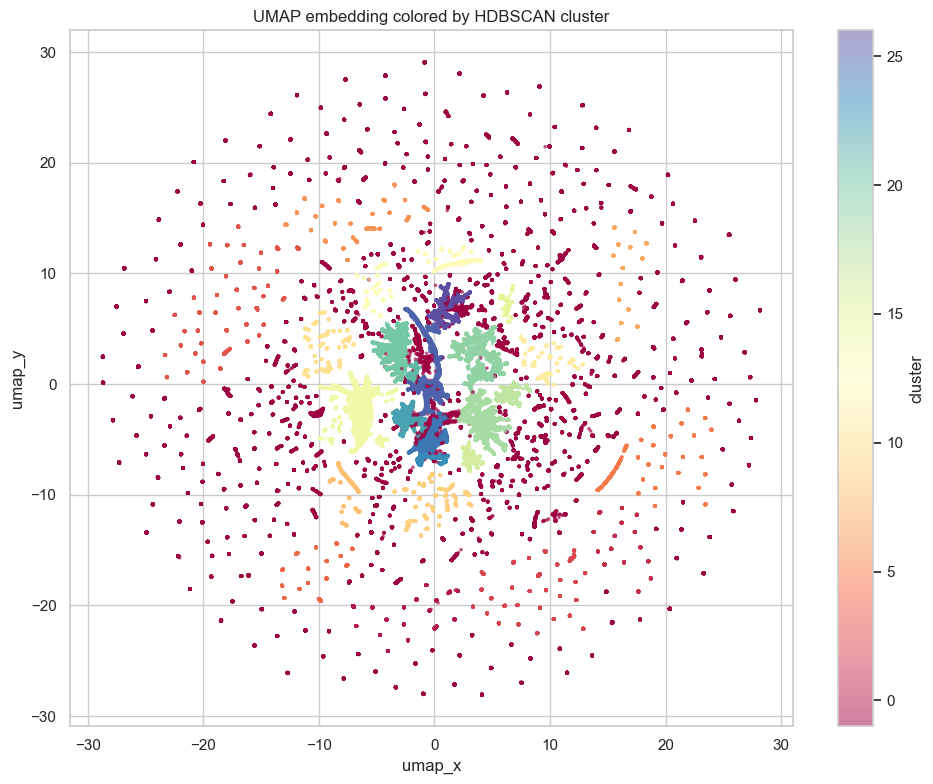

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    results["umap_x"], results["umap_y"],
    c=results["hdbscan_cluster"], cmap="Spectral", s=3, alpha=0.5,
)
ax.set_title("UMAP embedding colored by HDBSCAN cluster")
ax.set_xlabel("umap_x"); ax.set_ylabel("umap_y")
plt.colorbar(scatter, ax=ax, label="cluster")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "umap_hdbscan_scatter.png", dpi=150)
plt.show()


## 4. Validation baselines (report §4)


In [9]:
K_PRIMARY = max(2, n_clusters) if n_clusters else 8
print(f"K for K-Means / BGM reference: {K_PRIMARY}")

# PCA + K-Means
pca = PCA(n_components=min(SVD_COMPONENTS, X_scaled.shape[1]), random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
kmeans = KMeans(n_clusters=K_PRIMARY, random_state=RANDOM_STATE, n_init=10)
results["pca_kmeans_cluster"] = kmeans.fit_predict(X_pca)
print(f"PCA explained variance (sum): {pca.explained_variance_ratio_.sum():.3f}")

# SVD + HDBSCAN
svd = TruncatedSVD(n_components=min(SVD_COMPONENTS, X_scaled.shape[1] - 1), random_state=RANDOM_STATE)
X_svd = svd.fit_transform(X_scaled)
svd_clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=HDBSCAN_MIN_SAMPLES)
results["svd_hdbscan_cluster"] = svd_clusterer.fit_predict(X_svd)
results["svd_noise_flag"] = (results["svd_hdbscan_cluster"] == -1).astype(int)

# Bayesian GMM on SVD space
bgmm = BayesianGaussianMixture(
    n_components=min(K_PRIMARY + 2, 20),
    random_state=RANDOM_STATE,
    max_iter=300,
)
results["bgmm_cluster"] = bgmm.fit_predict(X_svd)
results["bgmm_max_prob"] = bgmm.predict_proba(X_svd).max(axis=1)


K for K-Means / BGM reference: 27
PCA explained variance (sum): 1.000


In [10]:
# SVD + Leiden (optional)
LEIDEN_AVAILABLE = False
try:
    import igraph as ig
    import leidenalg

    knn = kneighbors_graph(X_svd, n_neighbors=KNN_K, mode="distance", include_self=False)
    knn_sym = knn.maximum(knn.T)
    sources, targets = knn_sym.nonzero()
    weights = np.array(knn_sym[sources, targets]).flatten()
    g = ig.Graph(n=X_svd.shape[0], edges=list(zip(sources.tolist(), targets.tolist())), directed=False)
    g.es["weight"] = weights.tolist()
    partition = leidenalg.find_partition(
        g, leidenalg.RBConfigurationVertexPartition, weights="weight", seed=RANDOM_STATE
    )
    results["leiden_cluster"] = np.array(partition.membership)
    LEIDEN_AVAILABLE = True
    print(f"Leiden communities: {len(set(results['leiden_cluster']))}")
except ImportError as e:
    print("Leiden skipped (install leidenalg + python-igraph):", e)
    results["leiden_cluster"] = -1


Leiden communities: 17627


## 5. Compare methods


In [11]:
def safe_ari(a, b):
    if len(np.unique(a)) < 2 or len(np.unique(b)) < 2:
        return np.nan
    return adjusted_rand_score(a, b)

def safe_nmi(a, b):
    if len(np.unique(a)) < 2 or len(np.unique(b)) < 2:
        return np.nan
    return normalized_mutual_info_score(a, b)

primary = results["hdbscan_cluster"]
compare_cols = ["pca_kmeans_cluster", "svd_hdbscan_cluster", "bgmm_cluster"]
if LEIDEN_AVAILABLE:
    compare_cols.append("leiden_cluster")

metrics_rows = []
for col in compare_cols:
    metrics_rows.append({
        "method": col,
        "ari_vs_hdbscan": safe_ari(primary, results[col]),
        "nmi_vs_hdbscan": safe_nmi(primary, results[col]),
        "n_clusters": results[col].nunique(),
    })

# UMAP stability (second embedding, cluster with HDBSCAN again)
umap_stab = umap.UMAP(**{**UMAP_PARAMS, "random_state": 99})
emb_stab = umap_stab.fit_transform(X_scaled)
stab_labels = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=HDBSCAN_MIN_SAMPLES).fit_predict(emb_stab)
metrics_rows.append({
    "method": "umap_stability_run2",
    "ari_vs_hdbscan": safe_ari(primary, stab_labels),
    "nmi_vs_hdbscan": safe_nmi(primary, stab_labels),
    "n_clusters": len(set(stab_labels)) - (1 if -1 in stab_labels else 0),
})

metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df)

con.register("metrics_df_reg", metrics_df)
con.execute("CREATE OR REPLACE TABLE cluster_comparison_metrics_v1 AS SELECT * FROM metrics_df_reg")
con.unregister("metrics_df_reg")


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


,method,ari_vs_hdbscan,nmi_vs_hdbscan,n_clusters
0,pca_kmeans_cluster,0.219284,0.355390,27
1,svd_hdbscan_cluster,-0.041569,0.329015,54
2,bgmm_cluster,0.306793,0.297558,20
3,leiden_cluster,0.076006,0.425239,17627
4,umap_stability_run2,0.305612,0.492799,35


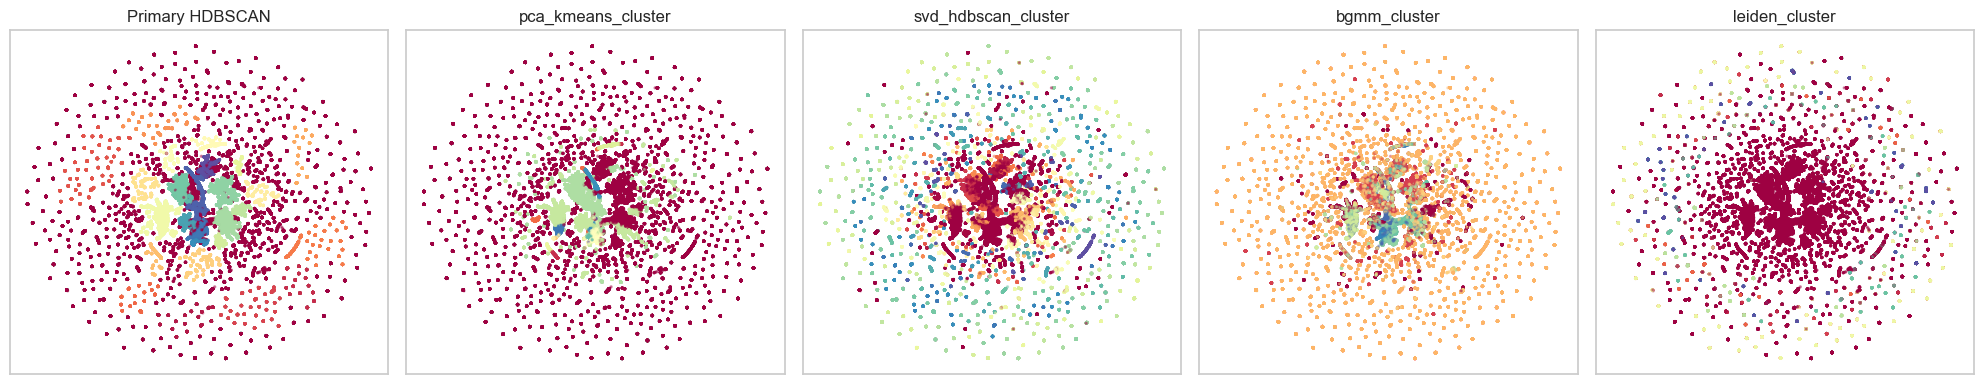

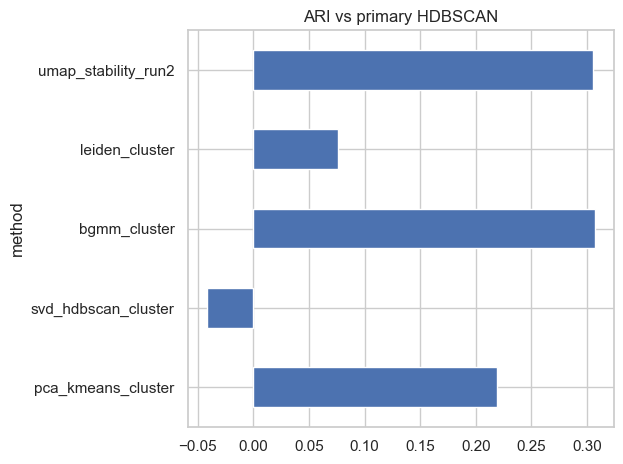

In [12]:
fig, axes = plt.subplots(1, len(compare_cols) + 1, figsize=(4 * (len(compare_cols) + 1), 4))
plot_specs = [("hdbscan_cluster", "Primary HDBSCAN")] + [(c, c) for c in compare_cols]
for ax, (col, title) in zip(axes, plot_specs):
    ax.scatter(results["umap_x"], results["umap_y"], c=results[col], cmap="Spectral", s=2, alpha=0.4)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "method_umap_comparison.png", dpi=150)
plt.show()

metrics_df.plot(x="method", y="ari_vs_hdbscan", kind="barh", legend=False, title="ARI vs primary HDBSCAN")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "method_comparison_ari.png", dpi=150)
plt.show()


In [13]:
# Cluster profiles (primary HDBSCAN): mean of top-varying features
cluster_profiles = []
for cid in sorted(results["hdbscan_cluster"].unique()):
    mask = results["hdbscan_cluster"] == cid
    row = {"hdbscan_cluster": cid, "n": mask.sum(), "behavioral_segment_name": results.loc[mask, "behavioral_segment_name"].iloc[0]}
    for j, f in enumerate(feature_names[:30]):
        row[f"mean_{f}"] = X_scaled[mask, j].mean()
    cluster_profiles.append(row)
profiles_df = pd.DataFrame(cluster_profiles)
profiles_df.to_csv(OUTPUT_DIR / "cluster_profiles.csv", index=False)
display(profiles_df.head(15))


,hdbscan_cluster,n,behavioral_segment_name,mean_persona_confidence,mean_persona_entropy,mean_mixed_persona_flag,mean_cuda_share,mean_genai_share,mean_robotics_share,mean_simulation_share,...,mean_has_activity_30_90d,mean_has_activity_90_180d,mean_log_activity_count_0_30d,mean_log_activity_count_30_90d,mean_log_activity_count_90_180d,mean_build_count_0_30d,mean_build_count_30_90d,mean_build_count_90_180d,mean_log_build_count_0_30d,mean_log_build_count_30_90d
0,-1,40342,Noise,-0.330988,0.302330,0.168931,0.374623,0.239023,0.058916,0.046131,...,0.303827,0.309281,0.482138,0.382900,0.267487,0.012493,0.068167,0.089287,0.005837,0.014760
1,0,987,Dormant_LowTouch_GenAI,-0.289296,0.053149,0.046606,0.601291,0.224771,0.014860,0.009890,...,0.163121,0.424519,0.513707,0.163121,0.267842,0.000000,0.000000,0.000000,0.000000,0.000000
2,1,822,Dormant_LowTouch_GenAI,-0.578559,0.380190,0.300487,0.162749,0.289888,0.089213,0.086577,...,0.083942,0.549878,0.366180,0.083942,0.346935,0.000000,0.000000,0.000000,0.000000,0.000000
3,2,1618,Active_Explorer_GenAI,-0.283896,0.107646,0.075402,0.373885,0.331258,0.019093,0.028096,...,0.252781,0.253399,0.605790,0.252781,0.159877,0.000000,0.000000,0.000000,0.000000,0.000000
4,3,2330,Cooling_GenAI,-0.559416,0.136131,0.129185,0.374063,0.201131,0.038054,0.031578,...,0.348069,0.329614,0.339903,0.370915,0.207963,0.000000,0.000000,0.000000,0.000000,0.000000
5,4,943,Cooling_CUDA,-0.579124,0.003602,0.002121,0.944940,-0.067828,0.000353,0.000884,...,0.545069,0.386002,0.109250,0.574844,0.243540,0.000000,0.000000,0.000000,0.000000,0.000000
6,5,1866,Cooling_GenAI,-0.137639,0.061243,0.056270,0.274589,0.443307,0.016546,0.015541,...,0.179528,0.520364,0.341999,0.190500,0.474082,0.000000,0.000000,0.000000,0.000000,0.000000
7,6,1634,Dormant_LowTouch_GenAI,-0.623640,0.263588,0.211750,0.459512,0.056482,0.067238,0.044814,...,0.250306,0.419217,0.365861,0.300783,0.299732,0.000000,0.000000,0.035496,0.000000,0.000000
8,7,748,Dormant_LowTouch_CUDA,-0.127657,0.058851,0.036096,0.899080,0.031974,0.012255,0.142937,...,0.327540,0.457219,0.215241,0.327540,0.352123,0.000000,0.000000,0.070856,0.000000,0.000000
9,8,977,Dormant_LowTouch_CUDA,-0.681710,0.989786,0.468782,0.700848,-0.032624,0.089771,0.122243,...,0.394063,0.405322,0.336370,0.465158,0.296371,0.000000,0.017400,0.000000,0.000000,0.012061


## 6. Persist outputs


In [14]:
results.to_parquet(OUTPUT_DIR / "cluster_results.parquet", index=False)

con.execute("DROP TABLE IF EXISTS developer_clusters_v1")
con.register("results_df", results)
con.execute("CREATE TABLE developer_clusters_v1 AS SELECT * FROM results_df")
con.unregister("results_df")

label_map_db = label_map.copy()
con.register("label_map_df", label_map_db)
con.execute("CREATE OR REPLACE TABLE cluster_label_map_v1 AS SELECT * FROM label_map_df")
con.unregister("label_map_df")

print("DuckDB tables: clustering_sample_v1, developer_clusters_v1, cluster_comparison_metrics_v1, cluster_label_map_v1")
print("Files:", list(OUTPUT_DIR.glob("*")))


DuckDB tables: clustering_sample_v1, developer_clusters_v1, cluster_comparison_metrics_v1, cluster_label_map_v1
Files: [PosixPath('outputs/clustering/cluster_profiles.csv'), PosixPath('outputs/clustering/umap_hdbscan_scatter.png'), PosixPath('outputs/clustering/preprocessor_v1.joblib'), PosixPath('outputs/clustering/cluster_results.parquet'), PosixPath('outputs/clustering/sample_features.parquet'), PosixPath('outputs/clustering/method_comparison_ari.png'), PosixPath('outputs/clustering/method_umap_comparison.png')]


## 8. Feature-space HDBSCAN (scaled features) + UMAP for visualization only

**Primary clustering:** HDBSCAN on `X_scaled` (median-imputed, `RobustScaler`-scaled numeric features).

**UMAP:** fit only for a 2D scatter plot; points are colored by feature-space cluster labels (not clustered in UMAP space).

Requires earlier cells through §2 (preprocessing) so `X_scaled`, `feature_names`, `y_ids`, `df_sample`, and `strata_meta` exist.


In [15]:
# HDBSCAN on full scaled feature matrix (not UMAP coordinates)
min_cluster_size_feat = max(50, int(len(X_scaled) * HDBSCAN_MIN_CLUSTER_FRAC))
print(f"Fitting feature-space HDBSCAN on X_scaled {X_scaled.shape} ...")
print(f"min_cluster_size={min_cluster_size_feat}, min_samples={HDBSCAN_MIN_SAMPLES}")

feature_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=min_cluster_size_feat,
    min_samples=HDBSCAN_MIN_SAMPLES,
    prediction_data=True,
)
hdbscan_feature_labels = feature_clusterer.fit_predict(X_scaled)

n_feat_clusters = len(set(hdbscan_feature_labels)) - (1 if -1 in hdbscan_feature_labels else 0)
n_feat_noise = (hdbscan_feature_labels == -1).sum()
print(
    f"Feature-space HDBSCAN: {n_feat_clusters} clusters (excl. noise), "
    f"noise={n_feat_noise:,} ({100.0 * n_feat_noise / len(hdbscan_feature_labels):.1f}%)"
)

# Compare to prior UMAP-space HDBSCAN (if hdb_labels exists from §3)
if "hdb_labels" in globals():
    print("\nAgreement with UMAP-space HDBSCAN (§3):")
    print(f"  ARI: {adjusted_rand_score(hdb_labels, hdbscan_feature_labels):.4f}")
    print(f"  NMI: {normalized_mutual_info_score(hdb_labels, hdbscan_feature_labels):.4f}")
else:
    print("Run §3 first to compare against UMAP-space HDBSCAN labels.")


Fitting feature-space HDBSCAN on X_scaled (100000, 107) ...
min_cluster_size=700, min_samples=25
Feature-space HDBSCAN: 46 clusters (excl. noise), noise=39,427 (39.4%)

Agreement with UMAP-space HDBSCAN (§3):
  ARI: -0.0361
  NMI: 0.3059


In [16]:
# Heuristic segment names for feature-space clusters
profile_feat = df_sample.copy()
profile_feat["hdbscan_feature_cluster"] = hdbscan_feature_labels

def label_cluster_feature(g):
    cid = g["hdbscan_feature_cluster"].iloc[0]
    if cid == -1:
        return "Noise"
    dorm_mode = g["dormancy_status"].mode().iloc[0] if len(g) else "Unknown"
    persona_mode = g["persona"].mode().iloc[0] if len(g) else "Other"
    build_share = g.get("build_share_0_30d", pd.Series([0])).mean()
    log_act = g.get(
        "log_activity_count_90_180d",
        g.get("log_activity_count_0_30d", pd.Series([0])),
    ).mean()
    if dorm_mode == "Active" and build_share >= 0.15:
        return f"Active_Builder_{persona_mode}"
    if dorm_mode in ("Dormant", "At_Risk") and log_act < 0.5:
        return f"Dormant_LowTouch_{persona_mode}"
    if dorm_mode == "Active":
        return f"Active_Explorer_{persona_mode}"
    if dorm_mode in ("Cooling", "At_Risk"):
        return f"Cooling_{persona_mode}"
    return f"Segment_{persona_mode}"

label_map_feature = pd.DataFrame([
    {"hdbscan_feature_cluster": cid, "behavioral_segment_name_feature": label_cluster_feature(g)}
    for cid, g in profile_feat.groupby("hdbscan_feature_cluster")
])

display(
    profile_feat.assign(
        behavioral_segment_name_feature=profile_feat["hdbscan_feature_cluster"].map(
            label_map_feature.set_index("hdbscan_feature_cluster")["behavioral_segment_name_feature"]
        )
    )
    .groupby(["hdbscan_feature_cluster", "behavioral_segment_name_feature"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .head(25)
)


,hdbscan_feature_cluster,behavioral_segment_name_feature,n
0,-1,Noise,39427
40,39,Cooling_GenAI,4941
27,26,Cooling_GenAI,3805
34,33,Cooling_CUDA,2943
43,42,Cooling_GenAI,2728
35,34,Cooling_CUDA,2086
36,35,Cooling_GenAI,1921
29,28,Active_Explorer_GenAI,1893
26,25,Active_Explorer_GenAI,1657
10,9,Active_Explorer_GenAI,1644


Reusing UMAP embedding from §3 for visualization.


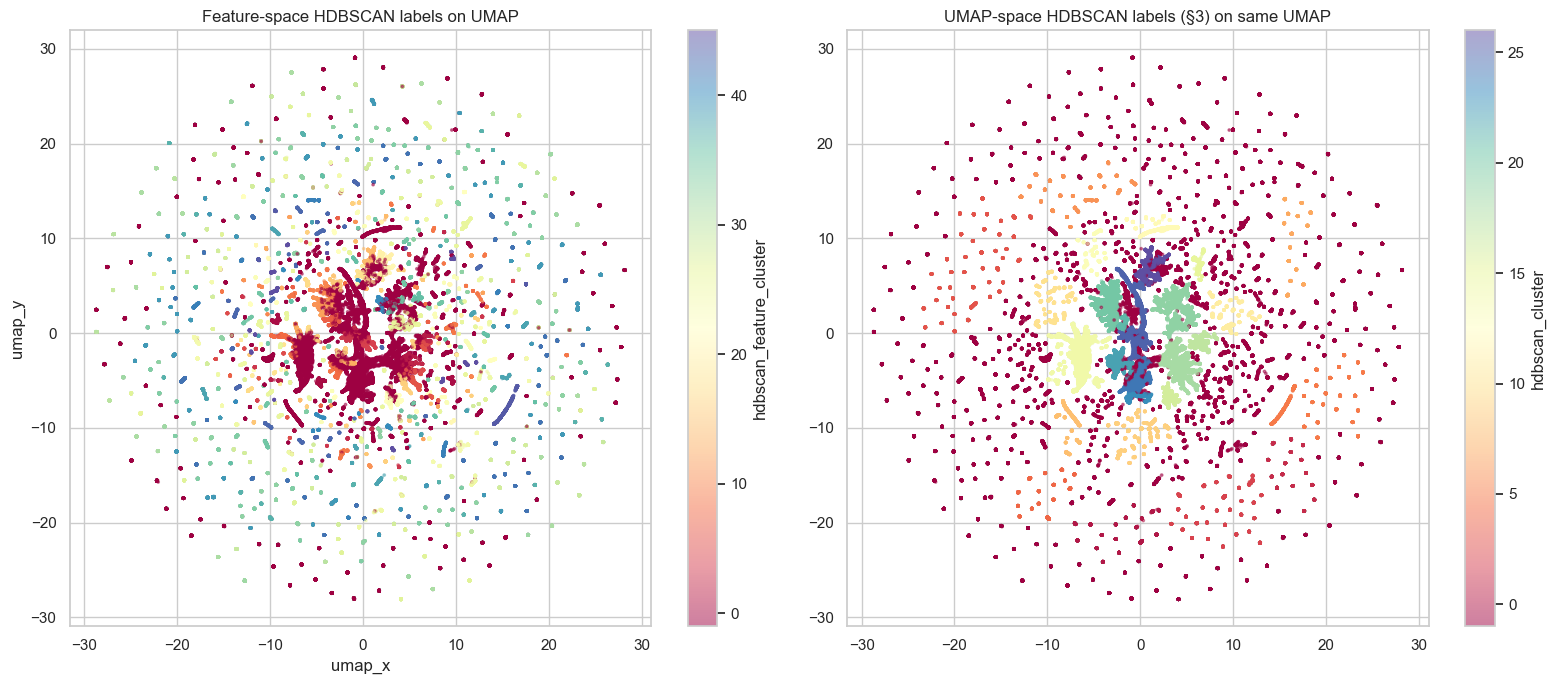

In [17]:
# UMAP for visualization only — color by feature-space clusters
if "embedding" not in globals():
    print("Fitting UMAP for visualization...")
    embedding_viz = umap.UMAP(**UMAP_PARAMS).fit_transform(X_scaled)
else:
    embedding_viz = embedding
    print("Reusing UMAP embedding from §3 for visualization.")

results_feature = pd.DataFrame({
    "developer_id": y_ids.values,
    "umap_x": embedding_viz[:, 0],
    "umap_y": embedding_viz[:, 1],
    "hdbscan_feature_cluster": hdbscan_feature_labels,
    "feature_cluster_probability": feature_clusterer.probabilities_,
    "feature_noise_flag": (hdbscan_feature_labels == -1).astype(int),
})
results_feature = results_feature.merge(label_map_feature, on="hdbscan_feature_cluster", how="left")
results_feature["behavioral_segment_name_feature"] = results_feature[
    "behavioral_segment_name_feature"
].fillna("Noise")
results_feature = pd.concat([results_feature, strata_meta.reset_index(drop=True)], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sc0 = axes[0].scatter(
    results_feature["umap_x"],
    results_feature["umap_y"],
    c=results_feature["hdbscan_feature_cluster"],
    cmap="Spectral",
    s=3,
    alpha=0.5,
)
axes[0].set_title("Feature-space HDBSCAN labels on UMAP")
axes[0].set_xlabel("umap_x")
axes[0].set_ylabel("umap_y")
plt.colorbar(sc0, ax=axes[0], label="hdbscan_feature_cluster")

if "hdb_labels" in globals():
    sc1 = axes[1].scatter(
        results_feature["umap_x"],
        results_feature["umap_y"],
        c=hdb_labels,
        cmap="Spectral",
        s=3,
        alpha=0.5,
    )
    axes[1].set_title("UMAP-space HDBSCAN labels (§3) on same UMAP")
    plt.colorbar(sc1, ax=axes[1], label="hdbscan_cluster")
else:
    axes[1].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "umap_colored_by_feature_hdbscan.png", dpi=150)
plt.show()


In [18]:
# Side-by-side cluster size comparison
size_feat = (
    results_feature["hdbscan_feature_cluster"]
    .value_counts()
    .rename_axis("cluster")
    .reset_index(name="n_feature_space")
)
if "hdb_labels" in globals():
    size_umap = (
        pd.Series(hdb_labels)
        .value_counts()
        .rename_axis("cluster")
        .reset_index(name="n_umap_space")
    )
    size_cmp = size_feat.merge(size_umap, on="cluster", how="outer").fillna(0).astype({"cluster": int})
    size_cmp = size_cmp.sort_values("n_feature_space", ascending=False)
    display(size_cmp.head(20))
else:
    display(size_feat.head(20))


,cluster,n_feature_space,n_umap_space
0,-1,39427,40342.0
40,39,4941,0.0
27,26,3805,2890.0
34,33,2943,0.0
43,42,2728,0.0
35,34,2086,0.0
36,35,1921,0.0
29,28,1893,0.0
26,25,1657,5434.0
10,9,1644,1586.0


In [19]:
# Merge feature-space labels into main results table (if §3–6 were run)
if "results" in dir():
    add_cols = results_feature[
        [
            "developer_id",
            "hdbscan_feature_cluster",
            "feature_cluster_probability",
            "feature_noise_flag",
            "behavioral_segment_name_feature",
        ]
    ]
    results = results.drop(
        columns=[
            c
            for c in [
                "hdbscan_feature_cluster",
                "feature_cluster_probability",
                "feature_noise_flag",
                "behavioral_segment_name_feature",
            ]
            if c in results.columns
        ],
        errors="ignore",
    ).merge(add_cols, on="developer_id", how="left")
    print("Added feature-space columns to `results`.")

results_feature.to_parquet(OUTPUT_DIR / "cluster_results_feature_space.parquet", index=False)

con.execute("DROP TABLE IF EXISTS developer_clusters_feature_v1")
con.register("results_feature_df", results_feature)
con.execute("CREATE TABLE developer_clusters_feature_v1 AS SELECT * FROM results_feature_df")
con.unregister("results_feature_df")

con.register("label_map_feature_df", label_map_feature)
con.execute(
    "CREATE OR REPLACE TABLE cluster_label_map_feature_v1 AS SELECT * FROM label_map_feature_df"
)
con.unregister("label_map_feature_df")

print("Wrote:", OUTPUT_DIR / "cluster_results_feature_space.parquet")
print("DuckDB: developer_clusters_feature_v1, cluster_label_map_feature_v1")


Added feature-space columns to `results`.
Wrote: outputs/clustering/cluster_results_feature_space.parquet
DuckDB: developer_clusters_feature_v1, cluster_label_map_feature_v1


## 9. Noise-reduction parameter sweep

Systematic HDBSCAN tuning to reduce **noise (-1)** vs baselines (~40%).

**Requires:** §2 (`X_scaled`, `df_sample`, `y_ids`). Optional: §3/§8 labels for ARI/NMI comparison.

Set `QUICK_GRID = True` for a fast pass (3 param combos only).


In [20]:
from sklearn.preprocessing import normalize
from sklearn.decomposition import TruncatedSVD
from sklearn.mixture import BayesianGaussianMixture

# --- Sweep controls ---
QUICK_GRID = False  # True: only 3 param combos per space (fast pass)
MCS_VALUES = [700, 500, 400, 250]
MS_VALUES = [25, 15, 10]
QUICK_PARAM_PAIRS = [(700, 25), (400, 15), (250, 10)]
EPSILON_VALUES = [0.0, 0.05, 0.1, 0.2, 0.5]
COSINE_CONFIGS = [(400, 15), (250, 10), (500, 15)]

noise_sweep_results = []


def run_hdbscan_eval(
    X,
    *,
    min_cluster_size,
    min_samples,
    cluster_selection_epsilon=0.0,
    metric="euclidean",
    store_labels=False,
):
    """Fit HDBSCAN and return summary metrics (labels optional to save memory)."""
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        cluster_selection_epsilon=cluster_selection_epsilon,
        metric=metric,
        prediction_data=False,
    )
    labels = clusterer.fit_predict(X)
    n = len(labels)
    noise_n = int((labels == -1).sum())
    non_noise = labels[labels >= 0]
    if len(non_noise):
        counts = pd.Series(non_noise).value_counts()
        n_clusters = len(counts)
        largest_cluster_pct = 100.0 * counts.max() / n
        smallest_nonnoise_cluster_n = int(counts.min())
    else:
        n_clusters = 0
        largest_cluster_pct = 0.0
        smallest_nonnoise_cluster_n = 0
    out = {
        "n": n,
        "n_clusters": n_clusters,
        "noise_n": noise_n,
        "noise_pct": 100.0 * noise_n / n,
        "largest_cluster_pct": largest_cluster_pct,
        "smallest_nonnoise_cluster_n": smallest_nonnoise_cluster_n,
        "min_cluster_size": min_cluster_size,
        "min_samples": min_samples,
        "cluster_selection_epsilon": cluster_selection_epsilon,
        "metric": metric,
    }
    if store_labels:
        out["labels"] = labels
    return out


def log_experiment(
    metrics,
    *,
    experiment_id,
    experiment_type,
    space,
    cohort,
    n_cohort=None,
):
    row = {
        "experiment_id": experiment_id,
        "experiment_type": experiment_type,
        "space": space,
        "cohort": cohort,
        "n_cohort": n_cohort if n_cohort is not None else metrics["n"],
        **{k: metrics[k] for k in metrics if k != "labels"},
    }
    row["over_fragmented"] = int(
        row["n_clusters"] > 60 or row["largest_cluster_pct"] < 5.0
    )
    noise_sweep_results.append(row)
    return row


# SVD embedding (reuse if from §4)
if "X_svd" not in globals():
    print("Fitting TruncatedSVD for sweep...")
    svd_sweep = TruncatedSVD(
        n_components=min(SVD_COMPONENTS, X_scaled.shape[1] - 1),
        random_state=RANDOM_STATE,
    )
    X_svd_sweep = svd_sweep.fit_transform(X_scaled)
else:
    X_svd_sweep = X_svd
    print("Reusing X_svd from earlier cells.")

X_scaled_cosine = normalize(X_scaled, norm="l2")

spaces = {"X_scaled": X_scaled, "X_svd_50": X_svd_sweep}

# --- Baselines (700, 25) ---
for space_name, X_mat in spaces.items():
    print(f"Baseline | {space_name} ...")
    m = run_hdbscan_eval(X_mat, min_cluster_size=700, min_samples=25)
    log_experiment(m, experiment_id="baseline", experiment_type="baseline", space=space_name, cohort="full_sample")

print("Baselines done.")


Reusing X_svd from earlier cells.
Baseline | X_scaled ...
Baseline | X_svd_50 ...
Baselines done.


In [21]:
# --- Parameter grid: min_cluster_size x min_samples ---
param_pairs = QUICK_PARAM_PAIRS if QUICK_GRID else [
    (mcs, ms) for mcs in MCS_VALUES for ms in MS_VALUES if not (mcs == 700 and ms == 25)
]
run_idx = 0
for space_name, X_mat in spaces.items():
    for mcs, ms in param_pairs:
            run_idx += 1
            print(f"[{run_idx}] param_grid | {space_name} | mcs={mcs} ms={ms}")
            m = run_hdbscan_eval(X_mat, min_cluster_size=mcs, min_samples=ms)
            log_experiment(
                m,
                experiment_id=f"grid_mcs{mcs}_ms{ms}",
                experiment_type="param_grid",
                space=space_name,
                cohort="full_sample",
            )

print(f"Param grid done ({run_idx} runs).")


[1] param_grid | X_scaled | mcs=700 ms=15
[2] param_grid | X_scaled | mcs=700 ms=10
[3] param_grid | X_scaled | mcs=500 ms=25
[4] param_grid | X_scaled | mcs=500 ms=15
[5] param_grid | X_scaled | mcs=500 ms=10
[6] param_grid | X_scaled | mcs=400 ms=25
[7] param_grid | X_scaled | mcs=400 ms=15
[8] param_grid | X_scaled | mcs=400 ms=10
[9] param_grid | X_scaled | mcs=250 ms=25
[10] param_grid | X_scaled | mcs=250 ms=15
[11] param_grid | X_scaled | mcs=250 ms=10
[12] param_grid | X_svd_50 | mcs=700 ms=15
[13] param_grid | X_svd_50 | mcs=700 ms=10
[14] param_grid | X_svd_50 | mcs=500 ms=25
[15] param_grid | X_svd_50 | mcs=500 ms=15
[16] param_grid | X_svd_50 | mcs=500 ms=10
[17] param_grid | X_svd_50 | mcs=400 ms=25
[18] param_grid | X_svd_50 | mcs=400 ms=15
[19] param_grid | X_svd_50 | mcs=400 ms=10
[20] param_grid | X_svd_50 | mcs=250 ms=25
[21] param_grid | X_svd_50 | mcs=250 ms=15
[22] param_grid | X_svd_50 | mcs=250 ms=10
Param grid done (22 runs).


In [22]:
# --- cluster_selection_epsilon sweep (SVD, mcs=400, ms=15) ---
for eps in EPSILON_VALUES:
    print(f"epsilon sweep | eps={eps}")
    m = run_hdbscan_eval(
        X_svd_sweep,
        min_cluster_size=400,
        min_samples=15,
        cluster_selection_epsilon=eps,
    )
    log_experiment(
        m,
        experiment_id=f"epsilon_{eps}",
        experiment_type="epsilon_sweep",
        space="X_svd_50",
        cohort="full_sample",
    )

# --- Cosine (L2-normalized X_scaled) ---
for mcs, ms in COSINE_CONFIGS:
    print(f"cosine | mcs={mcs} ms={ms}")
    m = run_hdbscan_eval(
        X_scaled_cosine,
        min_cluster_size=mcs,
        min_samples=ms,
        metric="euclidean",
    )
    log_experiment(
        m,
        experiment_id=f"cosine_mcs{mcs}_ms{ms}",
        experiment_type="cosine",
        space="X_scaled_cosine",
        cohort="full_sample",
    )

print("Epsilon + cosine sweeps done.")


epsilon sweep | eps=0.0
epsilon sweep | eps=0.05
epsilon sweep | eps=0.1
epsilon sweep | eps=0.2
epsilon sweep | eps=0.5
cosine | mcs=400 ms=15
cosine | mcs=250 ms=10
cosine | mcs=500 ms=15
Epsilon + cosine sweeps done.


In [23]:
# --- Narrower cohorts ---
cohort_masks = {
    "active_cooling": df_sample["dormancy_status"].isin(["Active", "Cooling"]).values,
    "min_activity_180d": (
        df_sample["activity_count_0_30d"].fillna(0)
        + df_sample["activity_count_30_90d"].fillna(0)
        + df_sample["activity_count_90_180d"].fillna(0)
    ).ge(3).values,
}

cohort_param_configs = [
    ("baseline", 700, 25, 0.0),
    ("mid", 400, 15, 0.0),
]

for cohort_name, mask in cohort_masks.items():
    n_cohort = int(mask.sum())
    X_sub_scaled = X_scaled[mask]
    X_sub_svd = X_svd_sweep[mask]
    sub_spaces = {"X_scaled": X_sub_scaled, "X_svd_50": X_sub_svd}
    for cfg_name, mcs, ms, eps in cohort_param_configs:
        for space_name, X_mat in sub_spaces.items():
            print(f"cohort={cohort_name} | {cfg_name} | {space_name} | n={n_cohort}")
            m = run_hdbscan_eval(
                X_mat,
                min_cluster_size=max(50, int(mcs * n_cohort / SAMPLE_N)),
                min_samples=ms,
                cluster_selection_epsilon=eps,
            )
            log_experiment(
                m,
                experiment_id=f"cohort_{cohort_name}_{cfg_name}_mcs{mcs}_ms{ms}",
                experiment_type="cohort_subset",
                space=space_name,
                cohort=cohort_name,
                n_cohort=n_cohort,
            )

# --- GMM benchmark (no noise label) ---
print("GMM benchmark on X_svd_50 ...")
bgmm_sweep = BayesianGaussianMixture(
    n_components=20, random_state=RANDOM_STATE, max_iter=300
)
bgmm_labels = bgmm_sweep.fit_predict(X_svd_sweep)
noise_sweep_results.append({
    "experiment_id": "bgmm_n20",
    "experiment_type": "gmm_benchmark",
    "space": "X_svd_50",
    "cohort": "full_sample",
    "n_cohort": len(bgmm_labels),
    "n": len(bgmm_labels),
    "n_clusters": len(np.unique(bgmm_labels)),
    "noise_n": 0,
    "noise_pct": 0.0,
    "largest_cluster_pct": 100.0 * pd.Series(bgmm_labels).value_counts().max() / len(bgmm_labels),
    "smallest_nonnoise_cluster_n": int(pd.Series(bgmm_labels).value_counts().min()),
    "min_cluster_size": np.nan,
    "min_samples": np.nan,
    "cluster_selection_epsilon": np.nan,
    "metric": "gmm",
    "over_fragmented": 0,
})

comparison_df = pd.DataFrame(noise_sweep_results).sort_values(["noise_pct", "n_clusters"])
comparison_df.to_csv(OUTPUT_DIR / "noise_sweep_comparison.csv", index=False)
print(f"Logged {len(comparison_df)} experiments.")
display(comparison_df.head(20))


cohort=active_cooling | baseline | X_scaled | n=62904
cohort=active_cooling | baseline | X_svd_50 | n=62904
cohort=active_cooling | mid | X_scaled | n=62904
cohort=active_cooling | mid | X_svd_50 | n=62904
cohort=min_activity_180d | baseline | X_scaled | n=27499
cohort=min_activity_180d | baseline | X_svd_50 | n=27499
cohort=min_activity_180d | mid | X_scaled | n=27499
cohort=min_activity_180d | mid | X_svd_50 | n=27499
GMM benchmark on X_svd_50 ...
Logged 41 experiments.


,experiment_id,experiment_type,space,cohort,n_cohort,n,n_clusters,noise_n,noise_pct,largest_cluster_pct,smallest_nonnoise_cluster_n,min_cluster_size,min_samples,cluster_selection_epsilon,metric,over_fragmented
40,bgmm_n20,gmm_benchmark,X_svd_50,full_sample,100000,100000,20,0,0.000000,51.810000,1,NaN,NaN,NaN,gmm,0
37,cohort_min_activity_180d_baseline_mcs700_ms25,cohort_subset,X_svd_50,min_activity_180d,27499,27499,3,7161,26.040947,72.078985,197,192.0,25.0,0.00,euclidean,0
36,cohort_min_activity_180d_baseline_mcs700_ms25,cohort_subset,X_scaled,min_activity_180d,27499,27499,3,7284,26.488236,71.977163,195,192.0,25.0,0.00,euclidean,0
9,grid_mcs400_ms10,param_grid,X_scaled,full_sample,100000,100000,67,26788,26.788000,4.941000,408,400.0,10.0,0.00,euclidean,1
28,epsilon_0.5,epsilon_sweep,X_svd_50,full_sample,100000,100000,63,27206,27.206000,5.265000,413,400.0,15.0,0.50,euclidean,1
12,grid_mcs250_ms10,param_grid,X_scaled,full_sample,100000,100000,106,27795,27.795000,2.728000,250,250.0,10.0,0.00,euclidean,1
23,grid_mcs250_ms10,param_grid,X_svd_50,full_sample,100000,100000,120,28088,28.088000,1.679000,252,250.0,10.0,0.00,euclidean,1
8,grid_mcs400_ms15,param_grid,X_scaled,full_sample,100000,100000,64,28237,28.237000,6.283000,408,400.0,15.0,0.00,euclidean,1
27,epsilon_0.2,epsilon_sweep,X_svd_50,full_sample,100000,100000,70,28317,28.317000,5.265000,407,400.0,15.0,0.20,euclidean,1
11,grid_mcs250_ms15,param_grid,X_scaled,full_sample,100000,100000,107,28646,28.646000,2.728000,250,250.0,15.0,0.00,euclidean,1


Top qualified configs per space:


,experiment_id,experiment_type,space,cohort,n_cohort,n,n_clusters,noise_n,noise_pct,largest_cluster_pct,smallest_nonnoise_cluster_n,min_cluster_size,min_samples,cluster_selection_epsilon,metric,over_fragmented
33,cohort_active_cooling_baseline_mcs700_ms25,cohort_subset,X_svd_50,active_cooling,62904,62904,36,18162,28.872568,7.989953,443,440.0,25.0,0.0,euclidean,0
32,cohort_active_cooling_baseline_mcs700_ms25,cohort_subset,X_scaled,active_cooling,62904,62904,33,18495,29.401946,7.854826,445,440.0,25.0,0.0,euclidean,0



Selected winner for refit:
  experiment_id: cohort_min_activity_180d_baseline_mcs700_ms25
  space: X_svd_50
  noise_pct: 26.04094694352522
  n_clusters: 3
  min_cluster_size: 192.0
  min_samples: 25.0
  cluster_selection_epsilon: 0.0
  metric: euclidean


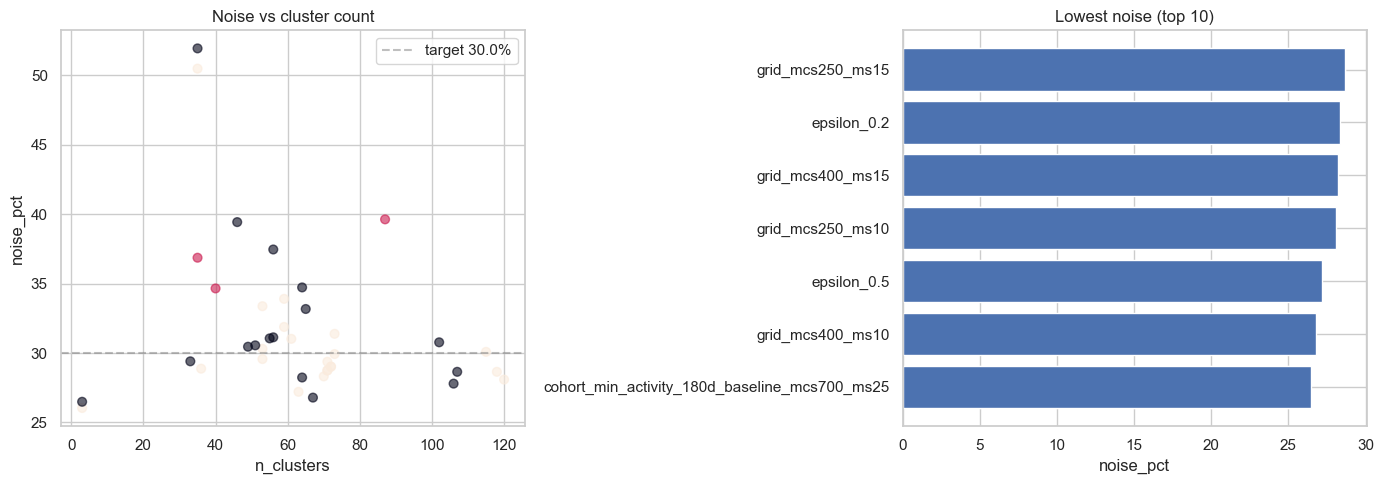

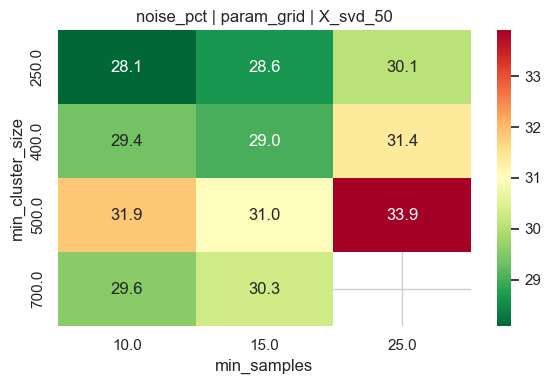


Agreement with §3/§8 for top 3 qualified configs:


,experiment_id,noise_pct,ari_vs_umap_hdbscan,nmi_vs_umap_hdbscan,ari_vs_feature_hdbscan,nmi_vs_feature_hdbscan
0,cohort_active_cooling_baseline_mcs700_ms25,28.872568,-0.041098,0.332842,0.611071,0.834558
1,cohort_active_cooling_baseline_mcs700_ms25,29.401946,-0.033502,0.326496,0.823608,0.932837


In [24]:
# --- Best configs under guardrails + plots ---
NOISE_TARGET = 30.0
NOISE_RELAX = 35.0
MIN_CLUSTERS, MAX_CLUSTERS = 5, 40
MIN_SMALL_CLUSTER = 200

hdbscan_only = comparison_df[comparison_df["experiment_type"] != "gmm_benchmark"].copy()

def qualifies(df, noise_cap):
    return df[
        (df["noise_pct"] <= noise_cap)
        & (df["n_clusters"] >= MIN_CLUSTERS)
        & (df["n_clusters"] <= MAX_CLUSTERS)
        & (df["smallest_nonnoise_cluster_n"] >= MIN_SMALL_CLUSTER)
        & (df["over_fragmented"] == 0)
    ]


qualified = qualifies(hdbscan_only, NOISE_TARGET)
if qualified.empty:
    qualified = qualifies(hdbscan_only, NOISE_RELAX)
    print(f"No configs under {NOISE_TARGET}% noise; relaxed to {NOISE_RELAX}%.")

best_configs = (
    qualified.sort_values(["noise_pct", "n_clusters"], ascending=[True, True])
    .groupby("space", as_index=False)
    .head(5)
)
best_configs.to_csv(OUTPUT_DIR / "noise_sweep_best_configs.csv", index=False)
print("Top qualified configs per space:")
display(best_configs)

# Overall winner for refit (prefer full_sample, non-cohort, lowest noise)
refit_candidates = qualified[
    qualified["cohort"] == "full_sample"
].sort_values(["noise_pct", "n_clusters"])

if refit_candidates.empty:
    refit_candidates = hdbscan_only.sort_values("noise_pct").head(10)

winner = refit_candidates.iloc[0].to_dict()
print("\nSelected winner for refit:")
for k in ["experiment_id", "space", "noise_pct", "n_clusters", "min_cluster_size", "min_samples", "cluster_selection_epsilon", "metric"]:
    print(f"  {k}: {winner.get(k)}")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_df = hdbscan_only.copy()
axes[0].scatter(
    plot_df["n_clusters"], plot_df["noise_pct"],
    c=plot_df["space"].astype("category").cat.codes, alpha=0.6, s=40,
)
axes[0].set_xlabel("n_clusters")
axes[0].set_ylabel("noise_pct")
axes[0].set_title("Noise vs cluster count")
axes[0].axhline(NOISE_TARGET, color="gray", ls="--", alpha=0.5, label=f"target {NOISE_TARGET}%")
axes[0].legend(handles=[], labels=[])

top10 = hdbscan_only.nsmallest(10, "noise_pct")
axes[1].barh(top10["experiment_id"].astype(str), top10["noise_pct"])
axes[1].set_xlabel("noise_pct")
axes[1].set_title("Lowest noise (top 10)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "noise_sweep_scatter.png", dpi=150)
plt.show()

# Heatmap: noise_pct for param_grid on X_svd_50
grid_svd = hdbscan_only[
    (hdbscan_only["experiment_type"] == "param_grid") & (hdbscan_only["space"] == "X_svd_50")
]
if len(grid_svd) >= 4:
    pivot = grid_svd.pivot_table(
        index="min_cluster_size", columns="min_samples", values="noise_pct", aggfunc="min"
    )
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn_r", ax=ax)
    ax.set_title("noise_pct | param_grid | X_svd_50")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "noise_sweep_heatmap_svd.png", dpi=150)
    plt.show()

# ARI/NMI vs baselines for top 3 qualified
if not qualified.empty and len(qualified) >= 1:
    print("\nAgreement with §3/§8 for top 3 qualified configs:")
    top3 = qualified.head(3)
    agreement_rows = []
    for _, row in top3.iterrows():
        X_mat = X_svd_sweep if row["space"] == "X_svd_50" else (
            X_scaled_cosine if row["space"] == "X_scaled_cosine" else X_scaled
        )
        mcs = int(row["min_cluster_size"])
        ms = int(row["min_samples"])
        eps = float(row["cluster_selection_epsilon"]) if pd.notna(row["cluster_selection_epsilon"]) else 0.0
        metric = row["metric"] if pd.notna(row["metric"]) and row["metric"] != "gmm" else "euclidean"
        m = run_hdbscan_eval(X_mat, min_cluster_size=mcs, min_samples=ms,
                             cluster_selection_epsilon=eps, metric=metric, store_labels=True)
        lbl = m["labels"]
        rec = {"experiment_id": row["experiment_id"], "noise_pct": row["noise_pct"]}
        if "hdb_labels" in globals():
            rec["ari_vs_umap_hdbscan"] = adjusted_rand_score(hdb_labels, lbl)
            rec["nmi_vs_umap_hdbscan"] = normalized_mutual_info_score(hdb_labels, lbl)
        if "hdbscan_feature_labels" in globals():
            rec["ari_vs_feature_hdbscan"] = adjusted_rand_score(hdbscan_feature_labels, lbl)
            rec["nmi_vs_feature_hdbscan"] = normalized_mutual_info_score(hdbscan_feature_labels, lbl)
        agreement_rows.append(rec)
    agreement_df = pd.DataFrame(agreement_rows)
    display(agreement_df)


Refitting winner on n=100000 | space=X_svd_50 | mcs=192 ms=25 eps=0.0
Best refit: 143 clusters, noise=27,942 (27.9%)


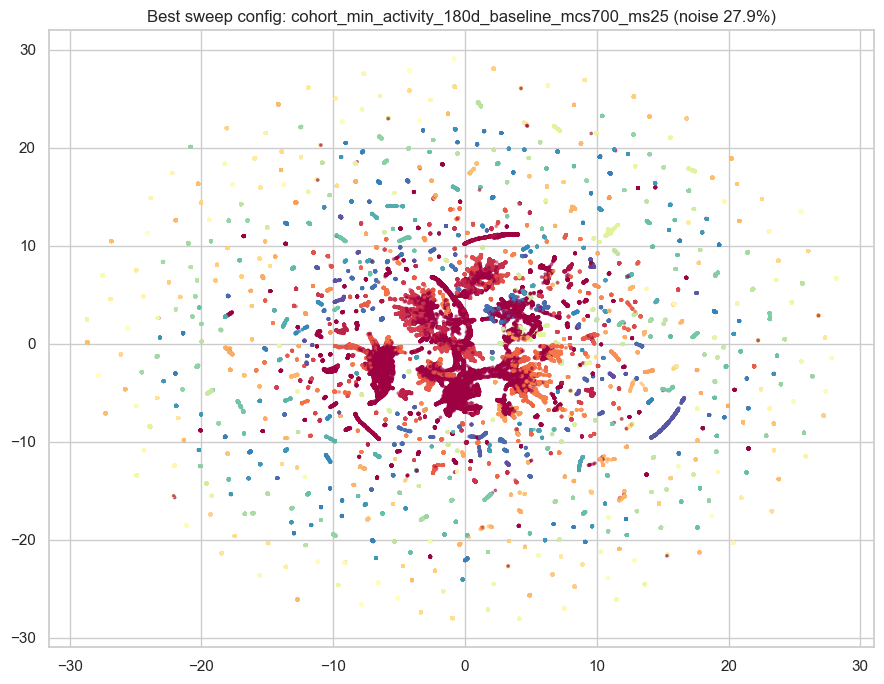

,hdbscan_best_cluster,behavioral_segment_name_best,n
0,-1,Noise,27942
114,113,Cooling_GenAI,1679
45,44,Active_Explorer_GenAI,1675
24,23,Active_Explorer_GenAI,1669
125,124,Cooling_CUDA,1389
105,104,Cooling_Unknown,1382
131,130,Cooling_CUDA,1348
23,22,Active_Builder_GenAI,1248
130,129,Cooling_CUDA,1165
135,134,Cooling_GenAI,1156


Saved cluster_results_best.parquet, developer_clusters_best_v1, cluster_noise_sweep_v1


In [25]:
# --- Refit winner on full 100k sample ---
w_space = winner["space"]
if w_space == "X_svd_50":
    X_refit = X_svd_sweep
elif w_space == "X_scaled_cosine":
    X_refit = X_scaled_cosine
else:
    X_refit = X_scaled

w_mcs = int(winner["min_cluster_size"])
w_ms = int(winner["min_samples"])
w_eps = float(winner["cluster_selection_epsilon"]) if pd.notna(winner.get("cluster_selection_epsilon")) else 0.0
w_metric = winner.get("metric", "euclidean")
if w_metric == "gmm" or (isinstance(w_metric, float) and np.isnan(w_metric)):
    w_metric = "euclidean"

print(f"Refitting winner on n={len(X_refit)} | space={w_space} | mcs={w_mcs} ms={w_ms} eps={w_eps}")

best_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=w_mcs,
    min_samples=w_ms,
    cluster_selection_epsilon=w_eps,
    metric=w_metric,
    prediction_data=True,
)
hdbscan_best_labels = best_clusterer.fit_predict(X_refit)
hdbscan_best_prob = best_clusterer.probabilities_

profile_best = df_sample.copy()
profile_best["hdbscan_best_cluster"] = hdbscan_best_labels

def label_cluster_best(g):
    cid = g["hdbscan_best_cluster"].iloc[0]
    if cid == -1:
        return "Noise"
    dorm_mode = g["dormancy_status"].mode().iloc[0] if len(g) else "Unknown"
    persona_mode = g["persona"].mode().iloc[0] if len(g) else "Other"
    build_share = g.get("build_share_0_30d", pd.Series([0])).mean()
    log_act = g.get("log_activity_count_90_180d", g.get("log_activity_count_0_30d", pd.Series([0]))).mean()
    if dorm_mode == "Active" and build_share >= 0.15:
        return f"Active_Builder_{persona_mode}"
    if dorm_mode in ("Dormant", "At_Risk") and log_act < 0.5:
        return f"Dormant_LowTouch_{persona_mode}"
    if dorm_mode == "Active":
        return f"Active_Explorer_{persona_mode}"
    if dorm_mode in ("Cooling", "At_Risk"):
        return f"Cooling_{persona_mode}"
    return f"Segment_{persona_mode}"

label_map_best = pd.DataFrame([
    {"hdbscan_best_cluster": cid, "behavioral_segment_name_best": label_cluster_best(g)}
    for cid, g in profile_best.groupby("hdbscan_best_cluster")
])

results_best = pd.DataFrame({
    "developer_id": y_ids.values,
    "hdbscan_best_cluster": hdbscan_best_labels,
    "cluster_probability_best": hdbscan_best_prob,
    "noise_flag_best": (hdbscan_best_labels == -1).astype(int),
    "winner_experiment_id": winner["experiment_id"],
    "winner_space": w_space,
    "winner_noise_pct_sweep": winner["noise_pct"],
})
results_best = results_best.merge(label_map_best, on="hdbscan_best_cluster", how="left")
results_best["behavioral_segment_name_best"] = results_best["behavioral_segment_name_best"].fillna("Noise")
results_best = pd.concat([results_best, strata_meta.reset_index(drop=True)], axis=1)

if "embedding" in globals():
    emb_best = embedding
else:
    emb_best = umap.UMAP(**UMAP_PARAMS).fit_transform(X_scaled)

results_best["umap_x"] = emb_best[:, 0]
results_best["umap_y"] = emb_best[:, 1]

n_best_noise = (hdbscan_best_labels == -1).sum()
n_best_clusters = len(set(hdbscan_best_labels)) - (1 if -1 in hdbscan_best_labels else 0)
print(f"Best refit: {n_best_clusters} clusters, noise={n_best_noise:,} ({100*n_best_noise/len(hdbscan_best_labels):.1f}%)")

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(results_best["umap_x"], results_best["umap_y"], c=results_best["hdbscan_best_cluster"],
           cmap="Spectral", s=3, alpha=0.5)
ax.set_title(f"Best sweep config: {winner['experiment_id']} (noise {100*n_best_noise/len(hdbscan_best_labels):.1f}%)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "noise_sweep_best_umap.png", dpi=150)
plt.show()

display(
    results_best.groupby(["hdbscan_best_cluster", "behavioral_segment_name_best"]).size()
    .reset_index(name="n").sort_values("n", ascending=False).head(20)
)

results_best.to_parquet(OUTPUT_DIR / "cluster_results_best.parquet", index=False)
con.execute("DROP TABLE IF EXISTS developer_clusters_best_v1")
con.register("results_best_df", results_best)
con.execute("CREATE TABLE developer_clusters_best_v1 AS SELECT * FROM results_best_df")
con.unregister("results_best_df")
con.register("comparison_df_reg", comparison_df)
con.execute("CREATE OR REPLACE TABLE cluster_noise_sweep_v1 AS SELECT * FROM comparison_df_reg")
con.unregister("comparison_df_reg")
print("Saved cluster_results_best.parquet, developer_clusters_best_v1, cluster_noise_sweep_v1")


### §9 interpretation

- **If noise barely moves** (~35–40% across all HDBSCAN settings): developer behavior in this cohort may not form crisp density clusters; consider **GMM** (0% noise by design), **rule-based** segments (dormancy × persona), or **supervised** 90d outcomes to pick a method.
- **If noise drops but `n_clusters` spikes** or `over_fragmented=1`: you are over-tuning — prefer a config with **5–40 clusters** and largest cluster **>5%** of sample.
- **If cohort subsets cut noise a lot**: publish segments for that **subset** explicitly (e.g. Active+Cooling only).
- **Winner selection rule:** lowest `noise_pct` among full-sample HDBSCAN runs with guardrails; see `noise_sweep_best_configs.csv` for alternates per space.
- Baselines §3/§8 are unchanged in `developer_clusters_v1` / `developer_clusters_feature_v1`.


## 10. Clustering by dormancy stratum (Team 1)

Run **separate** UMAP + HDBSCAN (+ GMM) per lifecycle group:

| Stratum | Cohort filter |
|---------|----------------|
| **active** | `is_activated=1`, `dormancy_status='Active'`, `has_activity_0_30d=1` |
| **cooling** | `dormancy_status='Cooling'` |
| **dormant** | `dormancy_status='Dormant'` |

Each stratum: persona-stratified sample (up to `SAMPLE_N`) → scaled numerics → **SVD(50)** → **HDBSCAN** → UMAP plots → cluster summary with Team-1-style names.

**Outputs:** `outputs/clustering/by_dormancy/{stratum}/`, DuckDB `developer_clusters_by_dormancy_v1`.

Run **§10a** (helpers) then **§10b** (run all strata).


In [29]:
# --- §10a: dormancy-stratum clustering helpers ---
from dataclasses import dataclass
from typing import Any

# Reconnect if you ran con.close() earlier
if "con" not in globals() or con is None:
    con = duckdb.connect(DB_PATH)
    print("Reconnected:", DB_PATH)

DORMANCY_OUTPUT = OUTPUT_DIR / "by_dormancy"
DORMANCY_OUTPUT.mkdir(parents=True, exist_ok=True)
DORMANCY_ORDER = ["active", "cooling", "dormant"]
DORMANCY_GMM_COMPONENTS = 20
DORMANCY_MIN_ROWS = 200

DORMANCY_COHORTS: dict[str, dict[str, Any]] = {
    "active": {
        "label": "Active (recent 30d activity)",
        "where_sql": """
            is_activated = 1
            AND COALESCE(dormancy_status, '') = 'Active'
            AND COALESCE(has_activity_0_30d, 0) = 1
        """,
        "stratify_col": "persona",
        "min_cluster_frac": 0.005,
        "min_samples": 15,
    },
    "cooling": {
        "label": "Cooling",
        "where_sql": "COALESCE(dormancy_status, '') = 'Cooling'",
        "stratify_col": "persona",
        "min_cluster_frac": 0.007,
        "min_samples": 20,
    },
    "dormant": {
        "label": "Dormant",
        "where_sql": "COALESCE(dormancy_status, '') = 'Dormant'",
        "stratify_col": "persona",
        "min_cluster_frac": 0.007,
        "min_samples": 25,
    },
}

if "should_exclude" not in globals():
    _DORM_EXCLUDE_EXACT = {
        "developer_id",
        "contact_created_date", "contact_first_activity_date", "contact_last_activity_date",
        "account_id", "account_type", "country", "region", "industry_segment_vertical",
        "program_application_source", "organization_english_name", "normalized_account_name",
        "wwfo_category", "wwfo_target_list",
        "behavior_journey_stage_30d", "behavior_journey_rank_30d",
        "current_journey_state_30d", "current_journey_rank_30d",
        "final_lifecycle_status", "persona", "persona_confidence_tier", "developer_effort_level",
        "dormancy_status", "user_type", "max_stage_reached",
        "last_meaningful_week_start", "lifetime_first_activity_date", "lifetime_last_activity_date",
        "missing_contact_metadata_flag",
    }
    _DORM_RAW_LIFETIME_SUPERSEDED = {
        "lifetime_activity_count", "lifetime_activity_score_sum", "lifetime_build_count",
        "lifetime_high_effort_count", "lifetime_total_confidence_weighted_effort",
        "lifetime_effort_x_activity_score_sum",
    }

    def should_exclude(col: str) -> bool:
        if col in _DORM_EXCLUDE_EXACT or col in _DORM_RAW_LIFETIME_SUPERSEDED:
            return True
        return col.startswith("first_activity_date") or col.startswith("last_activity_date")


@dataclass
class CohortRunResult:
    cohort_key: str
    cohort_n: int
    sample_n: int
    n_features: int
    hdbscan_clusters: int
    hdbscan_noise_pct: float
    gmm_components: int
    min_cluster_size: int
    output_dir: Path
    skipped: bool = False
    skip_reason: str = ""


def _dorm_sample_table(con, cohort_key, where_sql, stratify_col, sample_target, hash_salt):
    view = f"clustering_cohort_dormancy_{cohort_key}_v1"
    sample_table = f"clustering_sample_dormancy_{cohort_key}_v1"
    con.execute(f"CREATE OR REPLACE VIEW {view} AS SELECT * FROM dev_profile_final_v4 WHERE {where_sql}")
    cohort_n = con.execute(f"SELECT COUNT(*) FROM {view}").fetchone()[0]
    target = min(sample_target, cohort_n)
    if cohort_n == 0:
        return 0, 0, sample_table
    if cohort_n <= target:
        con.execute(f"CREATE OR REPLACE TABLE {sample_table} AS SELECT * FROM {view}")
        return cohort_n, cohort_n, sample_table
    con.execute(f"""
        CREATE OR REPLACE TABLE {sample_table} AS
        WITH cohort AS (SELECT * FROM {view}),
        targets AS (
            SELECT {stratify_col}, COUNT(*) AS stratum_n,
                GREATEST(1, CAST(ROUND(COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () * {target}) AS BIGINT)) AS target_n
            FROM cohort GROUP BY {stratify_col}
        ),
        ranked AS (
            SELECT c.*,
                ROW_NUMBER() OVER (PARTITION BY c.{stratify_col} ORDER BY hash(c.developer_id || '{hash_salt}')) AS rn,
                t.target_n
            FROM cohort c JOIN targets t USING ({stratify_col})
        )
        SELECT * EXCLUDE (rn, target_n) FROM ranked WHERE rn <= target_n
    """)
    sample_n = con.execute(f"SELECT COUNT(*) FROM {sample_table}").fetchone()[0]
    if sample_n > target:
        con.execute(f"""
            CREATE OR REPLACE TABLE {sample_table} AS
            SELECT * EXCLUDE (rn) FROM (
                SELECT *, ROW_NUMBER() OVER (ORDER BY hash(developer_id || '{hash_salt}')) AS rn
                FROM {sample_table}
            ) WHERE rn <= {target}
        """)
        sample_n = con.execute(f"SELECT COUNT(*) FROM {sample_table}").fetchone()[0]
    return cohort_n, sample_n, sample_table


def _dorm_build_features(con, sample_table):
    profile_cols = [r[0] for r in con.execute(
        "SELECT column_name FROM information_schema.columns WHERE table_name = 'dev_profile_final_v4' ORDER BY ordinal_position"
    ).fetchall()]
    sample_cols = [r[0] for r in con.execute(
        f"SELECT column_name FROM information_schema.columns WHERE table_name = '{sample_table}' ORDER BY ordinal_position"
    ).fetchall()]
    candidate_cols = [c for c in profile_cols if c in sample_cols and not should_exclude(c)]
    df = con.execute(f"SELECT * FROM {sample_table}").fetchdf()
    numeric_cols = [c for c in candidate_cols if pd.api.types.is_numeric_dtype(df[c])]
    preprocessor = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ])
    X_scaled = preprocessor.fit_transform(df[numeric_cols])
    keep_mask = np.var(X_scaled, axis=0) > 1e-12
    feature_names = [numeric_cols[i] for i, k in enumerate(keep_mask) if k]
    X_scaled = X_scaled[:, keep_mask]
    n_svd = min(SVD_COMPONENTS, X_scaled.shape[1] - 1, X_scaled.shape[0] - 1)
    svd = TruncatedSVD(n_components=n_svd, random_state=RANDOM_STATE)
    X_svd = svd.fit_transform(X_scaled)
    return df, X_scaled, feature_names, preprocessor, svd, X_svd


def _journey_segment_name_from_group(g, cohort_key):
    def mean_col(name):
        return float(g[name].mean()) if name in g.columns else 0.0

    learn = mean_col("lifetime_learn_count") + mean_col("log_activity_count_0_30d")
    build = mean_col("lifetime_build_count") + mean_col("build_count_0_30d")
    champ = mean_col("lifetime_champion_count")
    discover = mean_col("lifetime_discover_count")
    recent = mean_col("activity_count_0_30d")
    if build >= max(learn, champ, discover) and build > 0:
        base = "Builders"
    elif champ >= max(learn, build, discover) and champ > 0:
        base = "Champions"
    elif learn >= max(build, champ, discover) and learn > 0:
        base = "Learners"
    elif discover >= max(learn, build, champ) and discover > 0:
        base = "Explorers"
    elif recent > 0:
        base = "Active_Mixed"
    else:
        base = "Low_Signal"
    if cohort_key == "dormant" and build > learn and build > 0:
        return f"Dormant_Former_{base}"
    if cohort_key == "cooling":
        return f"Cooling_{base}"
    return base


def run_dormancy_cohort_notebook(con, cohort_key, output_root=DORMANCY_OUTPUT, sample_target=SAMPLE_N,
                                 gmm_components=DORMANCY_GMM_COMPONENTS, min_rows=DORMANCY_MIN_ROWS):
    cfg = DORMANCY_COHORTS[cohort_key]
    out_dir = Path(output_root) / cohort_key
    out_dir.mkdir(parents=True, exist_ok=True)
    cohort_n, sample_n, sample_table = _dorm_sample_table(
        con, cohort_key, cfg["where_sql"], cfg["stratify_col"], sample_target, HASH_SALT
    )
    if cohort_n == 0:
        return CohortRunResult(cohort_key, 0, 0, 0, 0, 0.0, gmm_components, 0, out_dir, True, "empty cohort")
    if sample_n < min_rows:
        return CohortRunResult(
            cohort_key, cohort_n, sample_n, 0, 0, 0.0, gmm_components, 0, out_dir, True, f"sample_n < {min_rows}"
        )

    df, X_scaled, feature_names, preprocessor, svd, X_svd = _dorm_build_features(con, sample_table)
    mcs = max(30, int(sample_n * cfg["min_cluster_frac"]))
    hdb = hdbscan.HDBSCAN(
        min_cluster_size=mcs, min_samples=cfg["min_samples"], metric="euclidean", cluster_selection_method="eom"
    )
    hdb_labels = hdb.fit_predict(X_svd)
    n_clust = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
    noise_pct = 100.0 * (hdb_labels == -1).sum() / len(hdb_labels)
    gmm_labels = BayesianGaussianMixture(
        n_components=gmm_components, random_state=RANDOM_STATE, max_iter=500
    ).fit_predict(X_svd)
    embedding = umap.UMAP(**UMAP_PARAMS).fit_transform(X_scaled)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, labels, title in [
        (axes[0], hdb_labels, f"{cfg['label']}: HDBSCAN ({noise_pct:.1f}% noise)"),
        (axes[1], gmm_labels, f"GMM k={gmm_components}"),
    ]:
        ax.scatter(embedding[:, 0], embedding[:, 1], c=labels, s=2, cmap="tab20", alpha=0.5)
        ax.set_title(title)
    plt.tight_layout()
    plt.savefig(out_dir / "umap_hdbscan_gmm.png", dpi=150)
    plt.show()

    results = pd.DataFrame({
        "developer_id": df["developer_id"].values,
        "dormancy_segment": cohort_key,
        "umap_x": embedding[:, 0],
        "umap_y": embedding[:, 1],
        "hdbscan_cluster": hdb_labels,
        "hdbscan_probability": getattr(hdb, "probabilities_", np.ones(len(hdb_labels))),
        "noise_flag": (hdb_labels == -1).astype(int),
        "gmm_cluster": gmm_labels,
        "persona": df["persona"].values,
        "dormancy_status": df["dormancy_status"].values,
        "current_journey_state_30d": df["current_journey_state_30d"].values,
        "final_lifecycle_status": df["final_lifecycle_status"].values,
    })
    results.to_parquet(out_dir / "cluster_results.parquet", index=False)

    profile_cols_summary = [
        c for c in [
            "activity_count_0_30d", "log_activity_count_0_30d", "build_count_0_30d",
            "lifetime_learn_count", "lifetime_build_count", "lifetime_champion_count",
            "lifetime_discover_count", "developer_effort_score", "days_since_last_activity",
            "cuda_share", "genai_share",
        ]
        if c in df.columns
    ]
    rows = []
    tmp = df.copy()
    tmp["hdbscan_cluster"] = hdb_labels
    for cid, g in tmp.groupby("hdbscan_cluster", observed=True):
        row = {
            "dormancy_segment": cohort_key,
            "hdbscan_cluster": int(cid),
            "n": len(g),
            "pct_of_sample": round(100.0 * len(g) / len(tmp), 2),
            "noise_flag": int(cid == -1),
        }
        if cid >= 0:
            row["top_persona"] = g["persona"].mode().iloc[0] if len(g) else ""
            if "current_journey_state_30d" in g.columns and g["current_journey_state_30d"].notna().any():
                row["top_journey_state_30d"] = g["current_journey_state_30d"].mode().iloc[0]
            if "final_lifecycle_status" in g.columns and g["final_lifecycle_status"].notna().any():
                row["top_lifecycle_status"] = g["final_lifecycle_status"].mode().iloc[0]
            row["behavioral_segment_name"] = _journey_segment_name_from_group(g, cohort_key)
        else:
            row["behavioral_segment_name"] = "Unclustered_Noise"
        for c in profile_cols_summary:
            m = g[c].mean()
            row[f"mean_{c}"] = None if pd.isna(m) else float(m)
        rows.append(row)
    pd.DataFrame(rows).sort_values("n", ascending=False).to_csv(out_dir / "cluster_summary_table.csv", index=False)
    joblib.dump({"preprocessor": preprocessor, "svd": svd, "feature_names": feature_names}, out_dir / "preprocessor.joblib")

    con.register(f"results_{cohort_key}", results)
    con.execute(f"DROP TABLE IF EXISTS developer_clusters_dormancy_{cohort_key}_v1")
    con.execute(f"CREATE TABLE developer_clusters_dormancy_{cohort_key}_v1 AS SELECT * FROM results_{cohort_key}")
    con.unregister(f"results_{cohort_key}")

    return CohortRunResult(
        cohort_key, cohort_n, sample_n, X_scaled.shape[1], n_clust, round(noise_pct, 2),
        gmm_components, mcs, out_dir,
    )


print("§10a helpers loaded.")


Reconnected: developer_project.duckdb
§10a helpers loaded.



Cohort: active — Active (recent 30d activity)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding som

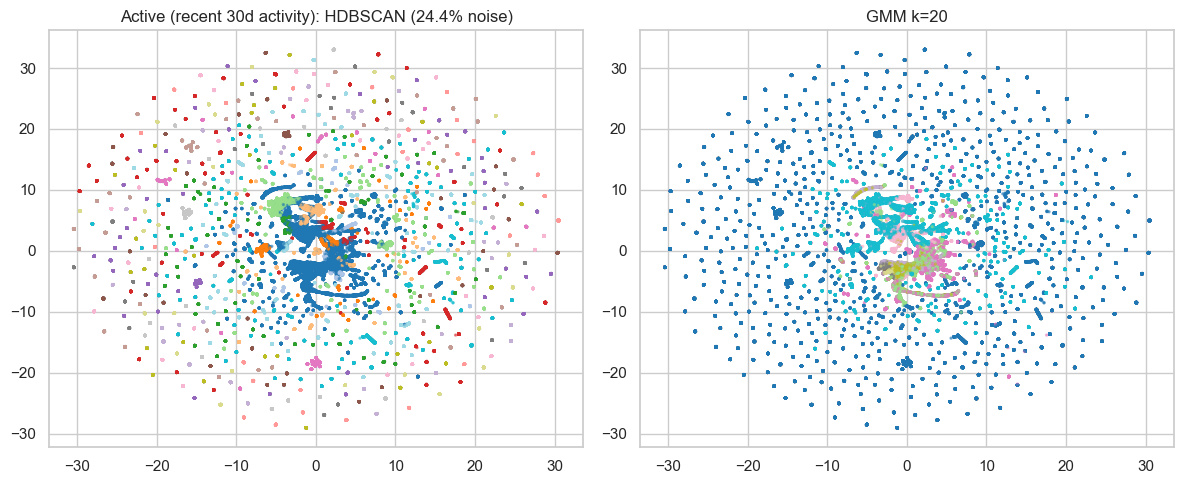

  cohort_n=418,049 sample_n=99,999 clusters=55 noise=24.42%

Cohort: cooling — Cooling


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['activity_per_active_day_0_30d' 'build_share_0_30d'
 'high_effort_share_0_30d' 'confidence_weighted_effort_per_activity_0_30d'
 'score_effort_misalignment_share_0_30d' 'days_since_last_activity_0_30d']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/spectral.

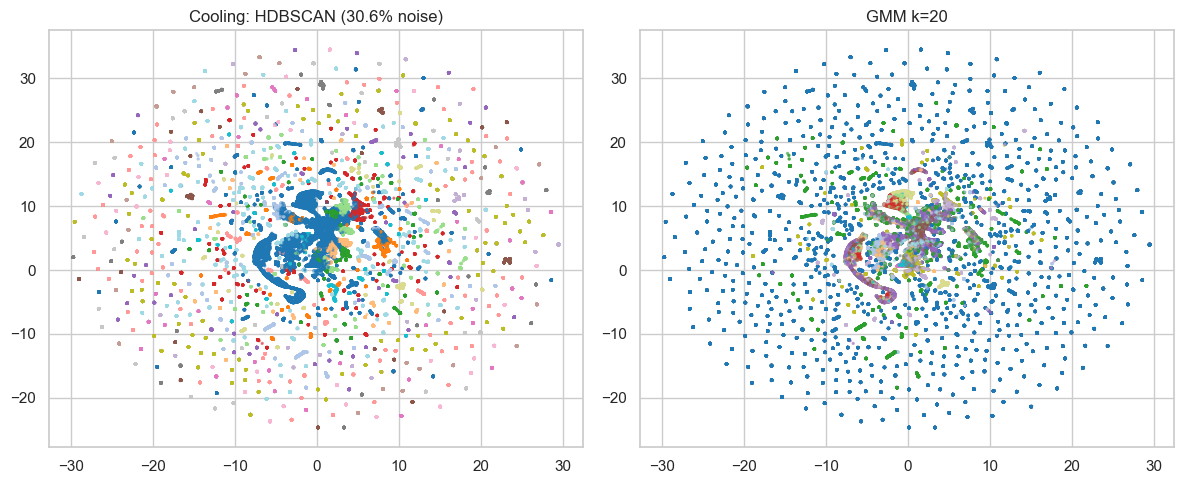

  cohort_n=356,500 sample_n=100,000 clusters=40 noise=30.61%

Cohort: dormant — Dormant


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['activity_per_active_day_0_30d' 'build_share_0_30d'
 'high_effort_share_0_30d' 'confidence_weighted_effort_per_activity_0_30d'
 'score_effort_misalignment_share_0_30d' 'days_since_last_activity_0_30d'
 'activity_velocity_0_30_vs_30_90' 'build_velocity_0_30_vs_30_90']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitte

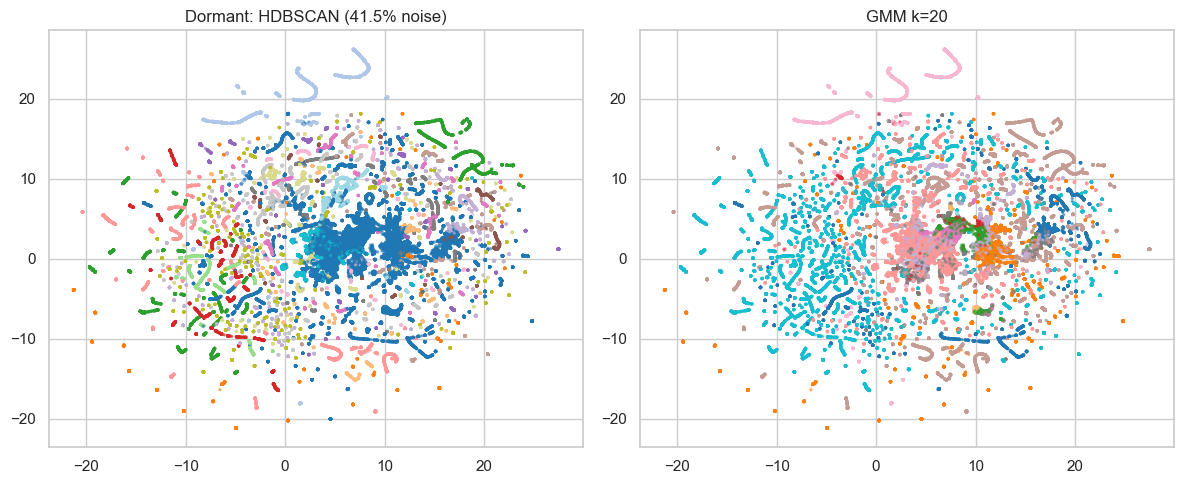

  cohort_n=5,304,852 sample_n=100,000 clusters=41 noise=41.49%

Cohort: unactivated — Unactivated


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['days_since_last_meaningful_week' 'days_since_last_activity'
 'activity_per_active_day_0_30d' 'build_share_0_30d'
 'high_effort_share_0_30d' 'confidence_weighted_effort_per_activity_0_30d'
 'score_effort_misalignment_share_0_30d' 'days_since_last_activity_0_30d'
 'activity_velocity_0_30_vs_30_90' 'build_velocity_0_30_vs_30_90'
 'effort_per_activity_lifetime' 'score_effort_misalignment_share_lifetime'
 'activity_per_active_week_lifetime' 'build_share_lifetime'
 'high_effort_share_lifetime']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.fram

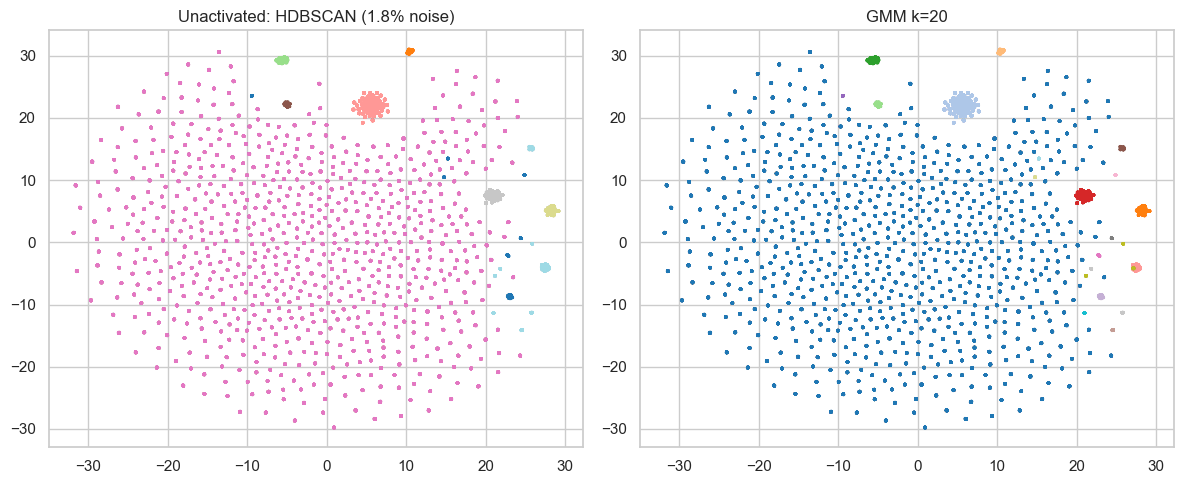

TypeError: float() argument must be a string or a real number, not 'NAType'

In [30]:
# --- §10b: run all dormancy strata ---
if con is None:
    raise RuntimeError("DuckDB connection is closed. Re-run §10a (or the config cell) before this cell.")

dormancy_summaries = []
dormancy_result_frames = []

for key in DORMANCY_ORDER:
    print(f"\n{'='*60}\nCohort: {key} — {DORMANCY_COHORTS[key]['label']}\n{'='*60}")
    res = run_dormancy_cohort_notebook(con, key)
    dormancy_summaries.append({k: v for k, v in res.__dict__.items() if k != "output_dir"})
    print(
        f"  cohort_n={res.cohort_n:,} sample_n={res.sample_n:,} "
        f"clusters={res.hdbscan_clusters} noise={res.hdbscan_noise_pct}%"
        + (f" SKIPPED: {res.skip_reason}" if res.skipped else "")
    )
    if not res.skipped:
        dormancy_result_frames.append(pd.read_parquet(res.output_dir / "cluster_results.parquet"))

dormancy_summary_df = pd.DataFrame(dormancy_summaries)
dormancy_summary_df.to_csv(DORMANCY_OUTPUT / "all_dormancy_run_summary.csv", index=False)
display(dormancy_summary_df)

if dormancy_result_frames:
    dormancy_combined = pd.concat(dormancy_result_frames, ignore_index=True)
    dormancy_combined.to_parquet(DORMANCY_OUTPUT / "cluster_results_all_dormancy.parquet", index=False)
    con.register("combined_clusters", dormancy_combined)
    con.execute("DROP TABLE IF EXISTS developer_clusters_by_dormancy_v1")
    con.execute("CREATE TABLE developer_clusters_by_dormancy_v1 AS SELECT * FROM combined_clusters")
    con.unregister("combined_clusters")
    summary_parts = [
        pd.read_csv(DORMANCY_OUTPUT / k / "cluster_summary_table.csv")
        for k in DORMANCY_ORDER
        if (DORMANCY_OUTPUT / k / "cluster_summary_table.csv").exists()
    ]
    if summary_parts:
        dormancy_summary_all = pd.concat(summary_parts, ignore_index=True)
        dormancy_summary_all.to_csv(DORMANCY_OUTPUT / "cluster_summary_table_all.csv", index=False)
        print("\nCombined cluster summary (preview):")
        display(dormancy_summary_all.head(25))

print(f"\nDone. Outputs under {DORMANCY_OUTPUT}")


## 7. Limitations (v1)

- **Sample-only (~100k):** UMAP/HDBSCAN on full ~9M developers is not attempted; assign full population in a follow-up (e.g. nearest centroid in scaled space or K-Means on PCA).
- **UMAP sensitivity:** See `umap_stability_run2` ARI/NMI vs primary — do not treat one map as ground truth.
- **Leaky labels excluded** from features; `dormancy_status` / `persona` used only for stratified sampling.
- **Supervised outcomes** (`churned_90d`, `retained_90d`, etc.) are required before choosing a final segmentation method (report §6).


In [33]:
# Close DuckDB connection
if "con" in globals() and con is not None:
    con.close()
    con = None
    print("DuckDB connection closed.")
else:
    print("No open `con` found.")

DuckDB connection closed.
